<a href="https://colab.research.google.com/github/Minnath-123/Project-HR-Employee-Attrition-analysis/blob/main/PROJECT_3_HR_EMPLOYEE_ATTRITION_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
#STEP:1 IMPORTING OPERATIONS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#STEP:2 CREATE DATASET
data={
"Empid:":[101,102,np.nan,101,102,103,103,102,np.nan],
"Department:":["Sales","HR","HR","Sales","HR","IT","Sales",np.nan,np.nan],
"Salary:":[10000,20000,10000,10000,20000,15000,np.nan,np.nan,20000],
"Experience:":[3,1,np.nan,3,1,2,np.nan,2,1],
"Attrition:":["Inactive","Inactive","Active","Inactive","Inactive","Inactive","Inactive","Inactive","Active"]
}
df=pd.DataFrame(data)
print(df)

   Empid: Department:  Salary:  Experience: Attrition:
0   101.0       Sales  10000.0          3.0   Inactive
1   102.0          HR  20000.0          1.0   Inactive
2     NaN          HR  10000.0          NaN     Active
3   101.0       Sales  10000.0          3.0   Inactive
4   102.0          HR  20000.0          1.0   Inactive
5   103.0          IT  15000.0          2.0   Inactive
6   103.0       Sales      NaN          NaN   Inactive
7   102.0         NaN      NaN          2.0   Inactive
8     NaN         NaN  20000.0          1.0     Active


In [25]:
#STEP:3 TO CALCULATE DUPLICATE IN DATASET
print(df.duplicated().sum())

2


In [10]:
#STEP:4 CLEAN THE DUPLICATE IN DATASET
print(df.drop_duplicates())

   Empid: Department:  Salary:  Experience: Attrition:
0   101.0       Sales  10000.0          3.0   Inactive
1   102.0          HR  20000.0          1.0   Inactive
2     NaN          HR  10000.0          NaN     Active
5   103.0          IT  15000.0          2.0   Inactive
6   103.0       Sales      NaN          NaN   Inactive
7   102.0         NaN      NaN          2.0   Inactive
8     NaN         NaN  20000.0          1.0     Active


In [11]:
#STEP:5 TO CALCULATE THE MISSING NULL VALUES
print(df.isnull().sum())

Empid:         2
Department:    2
Salary:        2
Experience:    2
Attrition:     0
dtype: int64


In [12]:
#STEP:6 TO HANDLE THE MISSING VALUES
df["Empid:"]=df["Empid:"].fillna(df["Empid:"].max()+1)
df["Department:"]=df["Department:"].fillna("unknown")
df["Salary:"]=df["Salary:"].fillna(df["Salary:"].median())
df["Experience:"]=df["Experience:"].fillna(df["Experience:"].mean())
print(df)

   Empid: Department:  Salary:  Experience: Attrition:
0   101.0       Sales  10000.0     3.000000   Inactive
1   102.0          HR  20000.0     1.000000   Inactive
2   104.0          HR  10000.0     1.857143     Active
3   101.0       Sales  10000.0     3.000000   Inactive
4   102.0          HR  20000.0     1.000000   Inactive
5   103.0          IT  15000.0     2.000000   Inactive
6   103.0       Sales  15000.0     1.857143   Inactive
7   102.0     unknown  15000.0     2.000000   Inactive
8   104.0     unknown  20000.0     1.000000     Active


In [13]:
#STEP:7 TO CALCULATE MEAN VALUES FOR SALARY,EXPERIENCE
print("Mean salary:",df["Salary:"].mean())
print("Mean Experience:",df["Experience:"].mean())

Mean salary: 15000.0
Mean Experience: 1.8571428571428572


In [14]:
#STEP:8 TO CALCULATE MEDIAN VALUES FOR SALARY,EXPERIENCE
print("Median salary:",df["Salary:"].median())
print("Median Experience:",df["Experience:"].median())

Median salary: 15000.0
Median Experience: 1.8571428571428572


In [15]:
#STEP:9 CALCULATE ATTRITION RATE USING GROUPBY
dept_attrition = df.groupby("Department:")["Attrition:"] .value_counts(normalize=True)*100
print("\nDepartment wise Attrition %:")
print(dept_attrition)
salary_attrition = df.groupby("Salary:")["Attrition:"] .value_counts(normalize=True)*100
print("\nSalary wise Attrition %:")
print(salary_attrition)
exp_attrition = df.groupby("Experience:")["Attrition:"] .value_counts(normalize=True)*100
print("\nExperience wise Attrition %:")
print(exp_attrition)


Department wise Attrition %:
Department:  Attrition:
HR           Inactive       66.666667
             Active         33.333333
IT           Inactive      100.000000
Sales        Inactive      100.000000
unknown      Active         50.000000
             Inactive       50.000000
Name: proportion, dtype: float64

Salary wise Attrition %:
Salary:  Attrition:
10000.0  Inactive       66.666667
         Active         33.333333
15000.0  Inactive      100.000000
20000.0  Inactive       66.666667
         Active         33.333333
Name: proportion, dtype: float64

Experience wise Attrition %:
Experience:  Attrition:
1.000000     Inactive       66.666667
             Active         33.333333
1.857143     Active         50.000000
             Inactive       50.000000
2.000000     Inactive      100.000000
3.000000     Inactive      100.000000
Name: proportion, dtype: float64


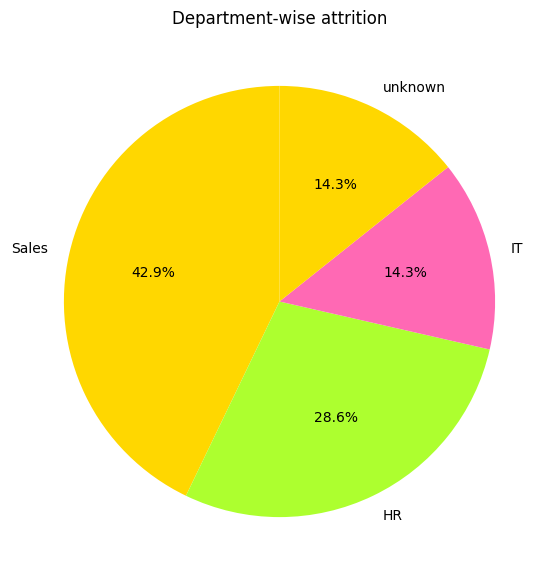

In [16]:
#STEP:10 TO CREATE A PIE CHART FOR DEPARTMENT ATTRITION
dept_attrition = df[df['Attrition:']=='Inactive']['Department:'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(dept_attrition, labels=dept_attrition.index,autopct='%1.1f%%',startangle=90, colors=['#FFD700','#ADFF2F','#FF69B4'])
plt.title('Department-wise attrition')
plt.show()

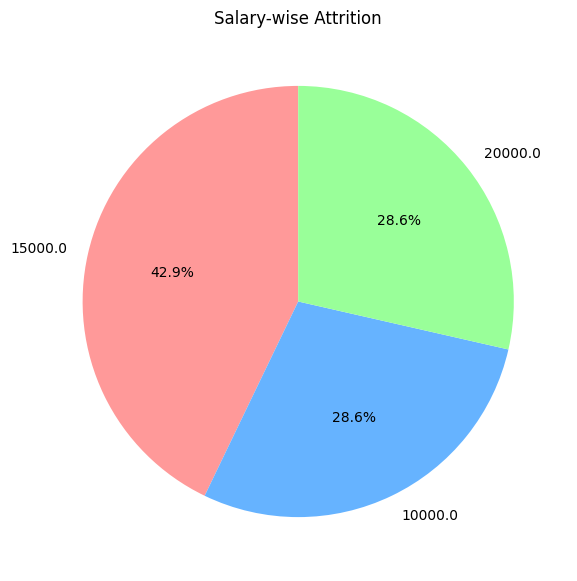

In [17]:
#STEP:11 TO CREATE PIE  CHART FOR SALARY ATTRITION
salary_attrition = df[df['Attrition:']=='Inactive']['Salary:'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(salary_attrition,autopct='%1.1f%%',labels=salary_attrition.index,  startangle=90, colors=['#FF9999','#66B3FF','#99FF99'])
plt.title('Salary-wise Attrition')
plt.show()

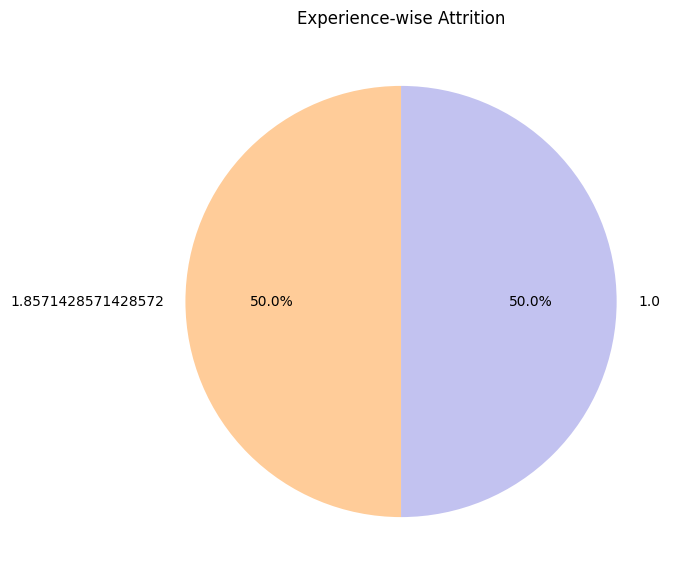

In [18]:
#STEP:12 TO CREATE PIE CHART FOR EXPERIENCE ATTRITION
exp_attrition = df[df['Attrition:']=='Active']['Experience:'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(exp_attrition, labels=exp_attrition.index, autopct='%1.1f%%', startangle=90, colors=['#FFCC99','#C2C2F0','#FFB3E6'])
plt.title('Experience-wise Attrition')
plt.show()

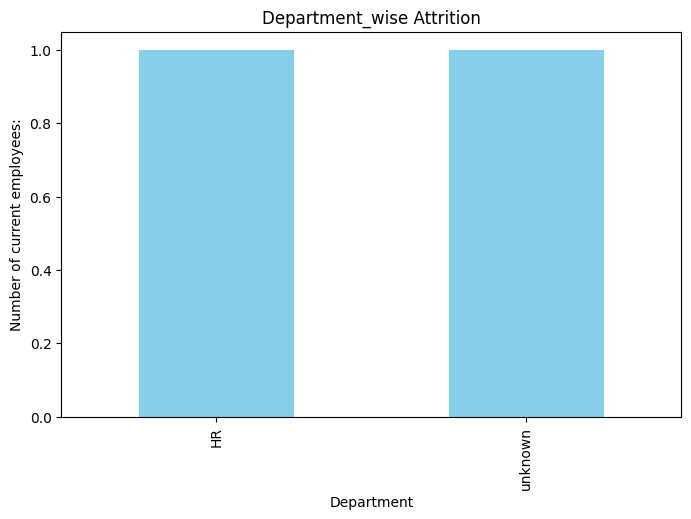

In [19]:
#STEP:13 TO CREATE BAR CHART FOR DEPARTMENT ATTRITION
dept_attrition = df[df['Attrition:']=='Active']['Department:'].value_counts()
plt.figure(figsize=(8,5))
dept_attrition.plot(kind="bar",color='skyblue')
plt.title("Department_wise Attrition")
plt.xlabel("Department")
plt.ylabel("Number of current employees:")
plt.show()

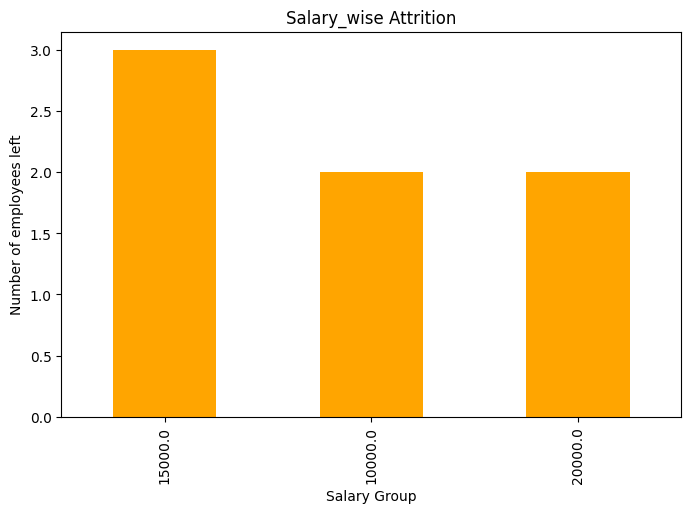

In [20]:
#STEP:14 TO CREATE BAR CHART FOR SALARY ATTRITION
salary_attrition = df[df['Attrition:']=='Inactive']['Salary:'].value_counts()
plt.figure(figsize=(8,5))
salary_attrition.plot(kind="bar", color='orange')
plt.title("Salary_wise Attrition")
plt.xlabel("Salary Group")
plt.ylabel("Number of employees left")
plt.show()

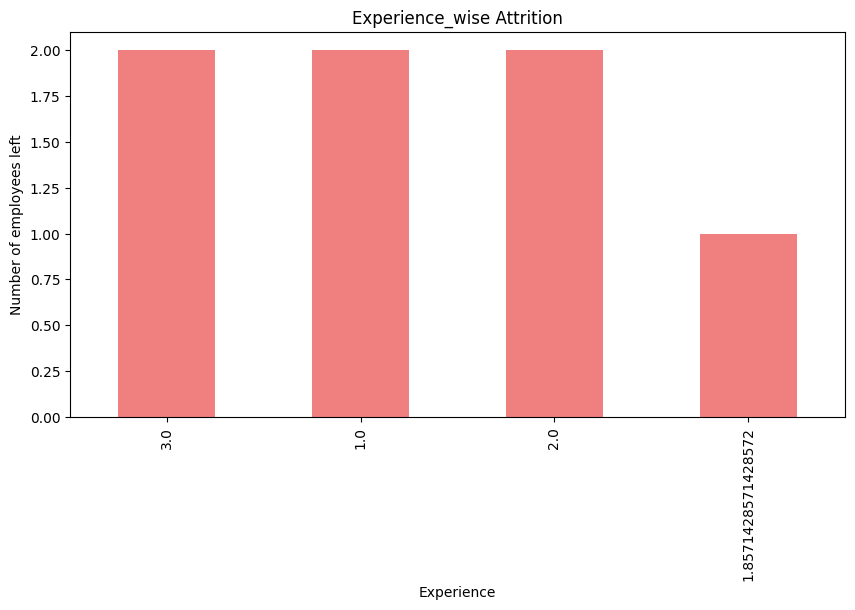

In [21]:
#STEP:15 CREATE BAR CHART FOR EXPERIENCE ATTRITION

exp_attrition = df[df['Attrition:']=='Inactive']['Experience:'].value_counts()
plt.figure(figsize=(10,5))
exp_attrition.plot(kind="bar", color='lightcoral')
plt.title("Experience_wise Attrition")
plt.xlabel("Experience")
plt.ylabel("Number of employees left")
plt.show()

In [22]:
#STEP:16 Attrition analysis
print("higher attrition Department:",dept_attrition.idxmax())
print("lowest attrition Salary:",salary_attrition.idxmin())
print("higher attrition Experience:",exp_attrition.idxmax())

higher attrition Department: HR
lowest attrition Salary: 10000.0
higher attrition Experience: 3.0


In [23]:
#STEP:17 KEY FACTORS CAUSING EMPLOYEES ATTRITON(WHY EMPLOYEES LEAVE)
print("Department wise attrition: Work stress in HR department")
print("Salary wise attrition:lowest salary for stressful job")
print("Experience wise attrition:Expect high salary with 3 years experience")

Department wise attrition: Work stress in HR department
Salary wise attrition:lowest salary for stressful job
Experience wise attrition:Expect high salary with 3 years experience


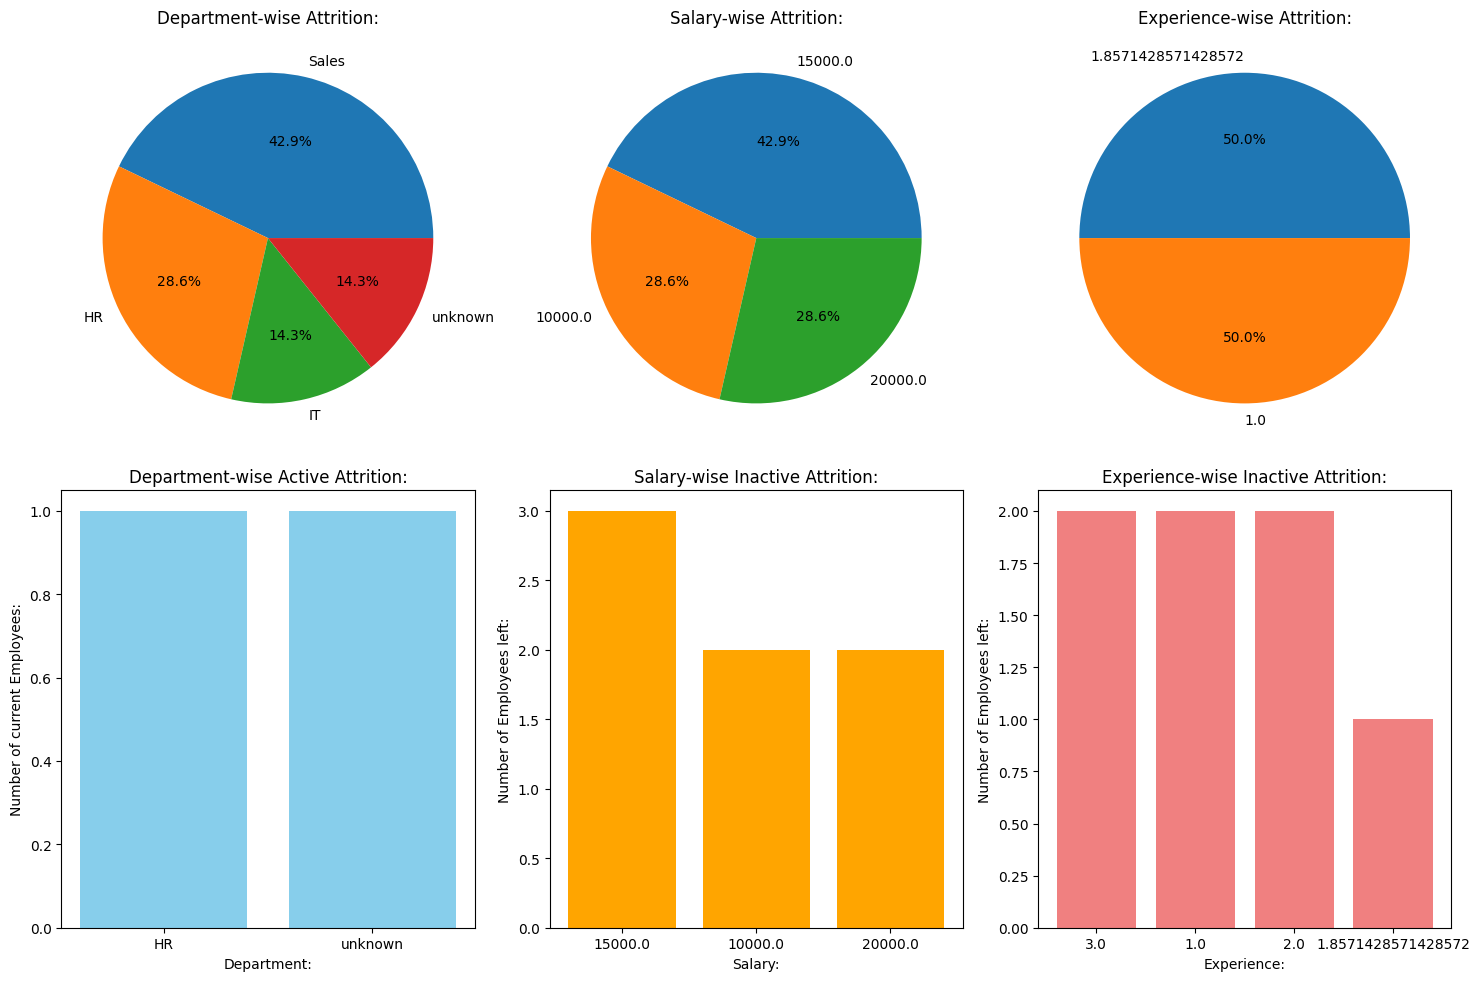

In [24]:
#STEP:18 CREATING SUBPLOTS DASH BOARD FOR CHARTS(PIE,BAR)
#SUBPLOTS FOR PIE CHARTS
#Active(or)Inactive value counts for pie charts
dept_attrition_inactive = df[df["Attrition:"]=="Inactive"]["Department:"].value_counts()
salary_attrition_inactive = df[df["Attrition:"]=="Inactive"]["Salary:"].value_counts()
exp_attrition_active = df[df["Attrition:"]=="Active"]["Experience:"].value_counts()
plt.figure(figsize=(15,10))

# Department-wise Inactive Attrition (Pie)
plt.subplot(2,3,1)
plt.pie(dept_attrition_inactive.values, labels=dept_attrition_inactive.index, autopct="%1.1f%%")
plt.title("Department-wise Attrition:")

# Salary-wise Inactive Attrition (Pie)
plt.subplot(2,3,2)
plt.pie(salary_attrition_inactive.values, labels=salary_attrition_inactive.index, autopct="%1.1f%%")
plt.title("Salary-wise Attrition:")

# Experience-wise Active Attrition (Pie)
plt.subplot(2,3,3)
plt.pie(exp_attrition_active.values, labels=exp_attrition_active.index, autopct="%1.1f%%")
plt.title("Experience-wise Attrition:")

#SUBPLOTS FOR BAR CHARTS

# Active(or)Inactive value count for Bar Charts
dept_attrition_active = df[df["Attrition:"]=="Active"]["Department:"].value_counts()
Salary_attrition_inactive = df[df["Attrition:"]=="Inactive"]["Salary:"].value_counts()
exp_attrition_inactive = df[df["Attrition:"]=="Inactive"]["Experience:"].value_counts()

# Department-wise Active Attrition (Bar)
plt.subplot(2,3,4)
plt.bar(dept_attrition_active.index, dept_attrition_active.values, color="skyblue")
plt.xlabel("Department:")
plt.ylabel("Number of current Employees:")
plt.title("Department-wise Active Attrition:") # Title updated to reflect 'Active'

#Salary-wise Inactive Attrition(Bar)
plt.subplot(2,3,5)
# Converted index to string for better display
plt.bar(salary_attrition_inactive.index.astype(str), salary_attrition_inactive.values, color="orange")
plt.xlabel("Salary:")
plt.ylabel("Number of Employees left:")
plt.title("Salary-wise Inactive Attrition:") # Title updated for clarity

#  Experience-wise Inactive Attrition (Bar)
plt.subplot(2,3,6)
# Converted index to string for better display
plt.bar(exp_attrition_inactive.index.astype(str), exp_attrition_inactive.values, color="lightcoral")
plt.xlabel("Experience:")
plt.ylabel("Number of Employees left:")
plt.title("Experience-wise Inactive Attrition:")

#To adjust the charts
plt.tight_layout()
plt.show()